# Prueba de progreso 2: Clustering de tráfico en Gipuzkoa

## Descripción del proyecto
- `20251208_datosvelocidad.csv`
- `20251208_datosvolumen.csv`
- `estaciones.csv`

En este trabajo he montado un análisis para sacar perfiles de tráfico por estación y por hora. La idea es comparar **KMeans**, **DBSCAN** y **Agglomerative Clustering**, y quedarme con el modelo que mejor separa los grupos según métricas internas.

## 1) Configuración del entorno y librerías

En esta celda cargo todas las librerías que voy a usar durante el cuaderno (análisis, visualización, preprocesado y clustering), fijo semilla para que los resultados sean reproducibles y defino las rutas de los archivos.

In [13]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, adjusted_rand_score

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

BASE_DIR = Path('.')
FILE_VEL = BASE_DIR / '20251208_datosvelocidad.csv'
FILE_VOL = BASE_DIR / '20251208_datosvolumen.csv'
FILE_EST = BASE_DIR / 'estaciones.csv'

print('Rutas detectadas:')
print(FILE_VEL.resolve())
print(FILE_VOL.resolve())
print(FILE_EST.resolve())

Rutas detectadas:
C:\Users\Asus\Documents\github\ml-dtg\p2\20251208_datosvelocidad.csv
C:\Users\Asus\Documents\github\ml-dtg\p2\20251208_datosvolumen.csv
C:\Users\Asus\Documents\github\ml-dtg\p2\estaciones.csv


## 2) Carga de datos de velocidad, volumen y estaciones

Aquí leo los tres CSV con separador `;`, limpio espacios sobrantes tanto en nombres de columnas como en valores, y hago una primera revisión rápida de dimensiones, tipos y muestras para comprobar que todo se ha cargado bien.

In [ ]:
def read_semicolon_csv(path: Path) -> pd.DataFrame:
    # Lo dejo en False para que pandas no me coja la primera columna como indice
    # cuando hay algun separador final de mas.
    df = pd.read_csv(path, sep=';', encoding='latin-1', dtype=str, index_col=False)
    # Quito columnas vacias que se crean por separadores finales
    df = df.dropna(axis=1, how='all')
    df.columns = [c.strip() for c in df.columns]
    for c in df.columns:
        df[c] = df[c].astype(str).str.strip()
        df[c] = df[c].replace({'': np.nan, 'nan': np.nan})
    # Reseteo indice para que todos los datasets queden alineados
    df = df.reset_index(drop=True)
    return df

vel = read_semicolon_csv(FILE_VEL)
vol = read_semicolon_csv(FILE_VOL)
est = read_semicolon_csv(FILE_EST)

print('Shapes:')
print('vel:', vel.shape)
print('vol:', vol.shape)
print('est:', est.shape)

print('\nDtypes (raw):')
print('vel\n', vel.dtypes.head())
print('vol\n', vol.dtypes.head())
print('est\n', est.dtypes.head())

print('\nMuestra velocidad:')
display(vel.head(3))
print('Muestra volumen:')
display(vol.head(3))
print('Muestra estaciones:')
display(est.head(3))

Shapes:
vel: (60180, 13)
vol: (10008, 15)
est: (85, 15)

Dtypes (raw):
vel
 Fecha       str
Hora        str
Sistema     str
ETD         str
Detector    str
dtype: object
vol
 Estacion            str
Fecha               str
Hora                str
Carril 1 ligeros    str
Carril 1 pesados    str
dtype: object
est
 System          str
ETD code        str
System code     str
Description     str
Country code    str
dtype: object

Muestra velocidad:


,Fecha,Hora,Sistema,ETD,Detector,0-50 (km/h),50-80 (km/h),80-120 (km/h),120-255 (km/h),Velocidad media (km/h),0-6 (m),6-999 (m),Vehículos totales
0,2025-12-08,01:00:00 - 01:30:00,N-634,"[N-634] 11-ETD SAN SEBASTIÁN-SANTANDER, N-634 ...",Lento SAN SEBASTIÁN,5,18,0,0,"56,3",22,1,23
1,2025-12-08,01:00:00 - 01:30:00,N-634,"[N-634] 11-ETD SAN SEBASTIÁN-SANTANDER, N-634 ...",Lento SANTANDER,1,29,1,0,"64,84",31,0,31
2,2025-12-08,01:00:00 - 01:30:00,N-I,"[N-I] 100-ETD VITORIA-GASTEIZ-LASARTE-ORIA, N-...",Central LASARTE-ORIA,0,0,11,2,"106,15",13,0,13


Muestra volumen:


,Estacion,Fecha,Hora,Carril 1 ligeros,Carril 1 pesados,Carril 2 ligeros,Carril 2 pesados,Carril 3 ligeros,Carril 3 pesados,Carril 4 ligeros,Carril 4 pesados,Carril 5 ligeros,Carril 5 pesados,Carril 6 ligeros,Carril 6 pesados
0,00001,08/12/2025,01:00,00043,00002,00000,00000,00000,00000,00041,00004,00013,00002,00000,00000
1,00001,08/12/2025,02:00,00051,00005,00000,00000,00000,00000,00017,00002,00016,00002,00000,00000
2,00001,08/12/2025,03:00,00019,00003,00000,00000,00000,00000,00011,00002,00007,00003,00000,00000


Muestra estaciones:


,System,ETD code,System code,Description,Country code,Country,Municipality code,Municipality,Territory code,Territory,Postal code,GPSX,GPSY,X,Y
0,GI-2132,1,1,"[GI-2132] 1-ETD LASARTE-ORIA-ASTIGARRAGA, GI-2...",108,España,NaN,NaN,20,Gipuzkoa,NaN,580428.65,4792191.27,-2.008765,43.278246
1,GI-636,3,1,"[GI-636] 3-ETD PASAIA-IRUN, GI-636 pk 7,900, G...",108,España,53,LEZO,20,Gipuzkoa,20100,594584.89,4798000.13,-1.83333,43.328896
2,N-634,11,1,"[N-634] 11-ETD SAN SEBASTIÁN-SANTANDER, N-634 ...",108,España,30,EIBAR,20,Gipuzkoa,20600,545592.28,4782339.1,-2.438889,43.192449


## 3) Limpieza, codificación y tipado de columnas

En este paso normalizo nombres de columnas, convierto variables numéricas (incluidos decimales con coma) y extraigo el `etd_code` para dejar una clave común que me permita cruzar correctamente los tres datasets.

In [ ]:
def to_numeric_series(s: pd.Series) -> pd.Series:
    return pd.to_numeric(s.astype(str).str.replace(',', '.', regex=False), errors='coerce')

# ---------- ESTACIONES: renombro y tipado ----------
est = est.rename(columns={
    'ETD code': 'etd_code',
    'Description': 'etd_description',
    'System': 'system'
})
est['etd_code'] = pd.to_numeric(est['etd_code'], errors='coerce').astype('Int64')
est['X'] = to_numeric_series(est['X'])
est['Y'] = to_numeric_series(est['Y'])

# ---------- VELOCIDAD: renombro, extraigo ETD y paso a numerico ----------
vel = vel.rename(columns={
    'Fecha': 'fecha',
    'Hora': 'hora_rango',
    'Sistema': 'system',
    'ETD': 'etd_description',
    'Detector': 'detector',
    '0-50 (km/h)': 'v_0_50',
    '50-80 (km/h)': 'v_50_80',
    '80-120 (km/h)': 'v_80_120',
    '120-255 (km/h)': 'v_120_255',
    'Velocidad media (km/h)': 'vel_media',
    '0-6 (m)': 'dist_0_6',
    '6-999 (m)': 'dist_6_999',
    'Vehículos totales': 'veh_totales'
})

vel['etd_code'] = pd.to_numeric(
    vel['etd_description'].str.extract(r'\]\s*(\d+)-ETD', expand=False),
    errors='coerce'
).astype('Int64')

for c in ['v_0_50', 'v_50_80', 'v_80_120', 'v_120_255', 'vel_media', 'dist_0_6', 'dist_6_999', 'veh_totales']:
    vel[c] = to_numeric_series(vel[c])

# ---------- VOLUMEN: renombro y convierto carriles ----------
vol = vol.rename(columns={
    'Estacion': 'estacion',
    'Fecha': 'fecha',
    'Hora': 'hora'
})
vol['etd_code'] = pd.to_numeric(vol['estacion'], errors='coerce').astype('Int64')

for c in vol.columns:
    if 'Carril' in c:
        vol[c] = pd.to_numeric(vol[c], errors='coerce')


## 4) Normalización temporal y unión de datasets

En esta parte alineo el tiempo entre fuentes: velocidad viene cada 30 minutos y volumen por hora. Lo llevo todo a una misma referencia temporal y luego hago la unión por `etd_code` + `datetime` para trabajar con una tabla integrada.

In [ ]:
# --- Tiempo en volumen (caso especial 24:00) ---
vol['fecha_dt'] = pd.to_datetime(vol['fecha'], format='%d/%m/%Y', errors='coerce')
vol['hora_int'] = pd.to_numeric(vol['hora'].str.split(':').str[0], errors='coerce')
vol['datetime'] = vol['fecha_dt'] + pd.to_timedelta(vol['hora_int'].fillna(0), unit='h')
# 24:00 lo interpreto como inicio del dia siguiente
mask_24 = vol['hora_int'] == 24
vol.loc[mask_24, 'datetime'] = vol.loc[mask_24, 'fecha_dt'] + pd.Timedelta(days=1)

# --- Tiempo en velocidad (de rango 30 min a inicio de intervalo) ---
vel['hora_inicio'] = vel['hora_rango'].str.split('-').str[0].str.strip()
vel['datetime_30m'] = pd.to_datetime(
    vel['fecha'] + ' ' + vel['hora_inicio'],
    format='%Y-%m-%d %H:%M:%S',
    errors='coerce'
)
vel['datetime'] = vel['datetime_30m'].dt.floor('h')

# --- Agregacion de velocidad a 1 hora por estacion ---
def weighted_avg(x_vals, w_vals):
    w_sum = np.nansum(w_vals)
    if w_sum == 0:
        return np.nan
    return np.nansum(x_vals * w_vals) / w_sum

vel_hour = (
    vel.groupby(['etd_code', 'datetime'], dropna=False)
       .apply(lambda g: pd.Series({
           'vel_veh_totales': g['veh_totales'].sum(skipna=True),
           'vel_media_pond': weighted_avg(g['vel_media'].values, g['veh_totales'].values),
           'v_0_50': g['v_0_50'].sum(skipna=True),
           'v_50_80': g['v_50_80'].sum(skipna=True),
           'v_80_120': g['v_80_120'].sum(skipna=True),
           'v_120_255': g['v_120_255'].sum(skipna=True),
           'dist_0_6': g['dist_0_6'].sum(skipna=True),
           'dist_6_999': g['dist_6_999'].sum(skipna=True)
       }))
       .reset_index()
)

# --- Union de fuentes ---
merged = vol.merge(vel_hour, on=['etd_code', 'datetime'], how='inner')
merged = merged.merge(
    est[['etd_code', 'system', 'etd_description', 'Territory', 'Municipality', 'X', 'Y']],
    on='etd_code',
    how='left'
)

print('Registros tras unión:', merged.shape)
print('Rango temporal:', merged['datetime'].min(), '->', merged['datetime'].max())
display(merged.head(3))

Registros tras unión: (9443, 33)
Rango temporal: 2025-12-08 01:00:00 -> 2025-12-14 23:00:00


,estacion,fecha,hora,Carril 1 ligeros,Carril 1 pesados,Carril 2 ligeros,Carril 2 pesados,Carril 3 ligeros,Carril 3 pesados,Carril 4 ligeros,Carril 4 pesados,Carril 5 ligeros,Carril 5 pesados,Carril 6 ligeros,Carril 6 pesados,etd_code,fecha_dt,hora_int,datetime,vel_veh_totales,vel_media_pond,v_0_50,v_50_80,v_80_120,v_120_255,dist_0_6,dist_6_999,system,etd_description,Territory,Municipality,X,Y
0,00001,08/12/2025,01:00,43,2,0,0,0,0,41,4,13,2,0,0,1,2025-12-08,1,2025-12-08 01:00:00,105.0,62.046857,13.0,86.0,6.0,0.0,97.0,8.0,GI-2132,"[GI-2132] 1-ETD LASARTE-ORIA-ASTIGARRAGA, GI-2...",Gipuzkoa,NaN,-2.008765,43.278246
1,00001,08/12/2025,02:00,51,5,0,0,0,0,17,2,16,2,0,0,1,2025-12-08,2,2025-12-08 02:00:00,93.0,67.257957,7.0,72.0,14.0,0.0,84.0,9.0,GI-2132,"[GI-2132] 1-ETD LASARTE-ORIA-ASTIGARRAGA, GI-2...",Gipuzkoa,NaN,-2.008765,43.278246
2,00001,08/12/2025,03:00,19,3,0,0,0,0,11,2,7,3,0,0,1,2025-12-08,3,2025-12-08 03:00:00,45.0,62.779333,6.0,35.0,4.0,0.0,37.0,8.0,GI-2132,"[GI-2132] 1-ETD LASARTE-ORIA-ASTIGARRAGA, GI-2...",Gipuzkoa,NaN,-2.008765,43.278246


## 5) Ingeniería de variables para clustering

A partir de los datos fusionados creo variables que resumen mejor el comportamiento del tráfico: volumen total, proporción de pesados, distribución por rangos de velocidad e indicadores temporales (hora, día de la semana, fin de semana).

In [ ]:
# Localizo columnas por carril
lig_cols = [c for c in merged.columns if 'ligeros' in c.lower()]
pes_cols = [c for c in merged.columns if 'pesados' in c.lower()]

for c in lig_cols + pes_cols:
    merged[c] = pd.to_numeric(merged[c], errors='coerce')

merged['vol_ligeros_total'] = merged[lig_cols].sum(axis=1, skipna=True)
merged['vol_pesados_total'] = merged[pes_cols].sum(axis=1, skipna=True)
merged['vol_total'] = merged['vol_ligeros_total'] + merged['vol_pesados_total']

merged['pct_pesados'] = np.where(
    merged['vol_total'] > 0,
    100 * merged['vol_pesados_total'] / merged['vol_total'],
    np.nan
)

activos = ((merged[lig_cols + pes_cols].fillna(0) > 0).sum(axis=1)).replace(0, np.nan)
merged['intensidad_media_carril'] = merged['vol_total'] / activos

# Porcentaje de cada rango de velocidad
merged['speed_bins_total'] = merged[['v_0_50', 'v_50_80', 'v_80_120', 'v_120_255']].sum(axis=1, skipna=True)
for c in ['v_0_50', 'v_50_80', 'v_80_120', 'v_120_255']:
    merged[f'pct_{c}'] = np.where(
        merged['speed_bins_total'] > 0,
        100 * merged[c] / merged['speed_bins_total'],
        np.nan
    )

merged['pct_dist_0_6'] = np.where(
    (merged['dist_0_6'] + merged['dist_6_999']) > 0,
    100 * merged['dist_0_6'] / (merged['dist_0_6'] + merged['dist_6_999']),
    np.nan
)

merged['hora'] = merged['datetime'].dt.hour
merged['dia_semana'] = merged['datetime'].dt.dayofweek
merged['es_fin_de_semana'] = (merged['dia_semana'] >= 5).astype(int)

print('Variables derivadas creadas.')
display(merged[['etd_code', 'datetime', 'vol_total', 'pct_pesados', 'vel_media_pond', 'pct_v_0_50', 'pct_v_80_120']].head(5))

Variables derivadas creadas.


,etd_code,datetime,vol_total,pct_pesados,vel_media_pond,pct_v_0_50,pct_v_80_120
0,1,2025-12-08 01:00:00,105,7.619048,62.046857,12.380952,5.714286
1,1,2025-12-08 02:00:00,93,9.677419,67.257957,7.526882,15.053763
2,1,2025-12-08 03:00:00,45,17.777778,62.779333,13.333333,8.888889
3,1,2025-12-08 04:00:00,42,28.571429,72.261667,4.761905,26.190476
4,1,2025-12-08 05:00:00,33,15.151515,65.759091,6.060606,9.090909


## 6) Preprocesado numérico y escalado

Aquí selecciono las variables finales para modelar, imputo faltantes con la mediana y escalo con `MinMaxScaler` para que todos los algoritmos comparen en las mismas condiciones.

In [18]:
features = [
    'vol_total', 'vol_ligeros_total', 'vol_pesados_total', 'pct_pesados', 'intensidad_media_carril',
    'vel_veh_totales', 'vel_media_pond', 'pct_v_0_50', 'pct_v_50_80', 'pct_v_80_120', 'pct_v_120_255',
    'pct_dist_0_6', 'hora', 'dia_semana', 'es_fin_de_semana', 'X', 'Y'
]

df_model = merged.copy()
X_raw = df_model[features]

preprocess = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler())
])

X = preprocess.fit_transform(X_raw)

print('Matriz de entrenamiento:', X.shape)
print('Número de estaciones distintas:', df_model['etd_code'].nunique())

Matriz de entrenamiento: (9443, 17)
Número de estaciones distintas: 77


## 7) Entrenamiento simultáneo de KMeans, DBSCAN y Agglomerative

En esta celda lanzo una primera versión de los tres algoritmos con parámetros base para tener una referencia inicial y ver qué enfoque se adapta mejor al dataset.

In [ ]:
from sklearn.neighbors import NearestNeighbors


def suggest_dbscan_eps(X_data, min_samples=10, quantile=0.9):
    """Estimo un eps razonable usando la distancia al k-esimo vecino."""
    nn = NearestNeighbors(n_neighbors=min_samples, metric='euclidean')
    nn.fit(X_data)
    distances, _ = nn.kneighbors(X_data)
    k_dist = distances[:, -1]
    return float(np.quantile(k_dist, quantile))


def eval_cluster_labels(X_data, labels, max_eval_samples=5000):
    labels = np.array(labels)
    mask = labels != -1
    n_clusters_total = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = int((labels == -1).sum())
    noise_ratio = n_noise / len(labels)

    if n_clusters_total >= 2 and mask.sum() >= 3 and len(np.unique(labels[mask])) >= 2:
        # Para que no se haga eterno con muchos datos, evalúo sobre muestra.
        if mask.sum() > max_eval_samples:
            rng = np.random.default_rng(SEED)
            idx = rng.choice(np.where(mask)[0], size=max_eval_samples, replace=False)
            X_eval = X_data[idx]
            y_eval = labels[idx]
        else:
            X_eval = X_data[mask]
            y_eval = labels[mask]

        sil = silhouette_score(X_eval, y_eval)
        cal = calinski_harabasz_score(X_eval, y_eval)
        dav = davies_bouldin_score(X_eval, y_eval)
    else:
        sil, cal, dav = np.nan, np.nan, np.nan

    return {
        'n_clusters': n_clusters_total,
        'n_noise': n_noise,
        'noise_ratio': noise_ratio,
        'silhouette': sil,
        'calinski_harabasz': cal,
        'davies_bouldin': dav,
    }


base_eps = suggest_dbscan_eps(X, min_samples=10, quantile=0.9)
print(f'eps base sugerido para DBSCAN (MinMax): {base_eps:.4f}')

base_models = {
    'KMeans': KMeans(n_clusters=4, random_state=SEED, n_init=20),
    'Agglomerative': AgglomerativeClustering(n_clusters=4, linkage='ward'),
    'DBSCAN': DBSCAN(eps=base_eps, min_samples=10)
}

base_rows = []
base_labels = {}

for name, model in base_models.items():
    labels = model.fit_predict(X)
    base_labels[name] = labels
    m = eval_cluster_labels(X, labels)
    m['modelo'] = name
    m['params'] = str(model.get_params())
    base_rows.append(m)

base_results = pd.DataFrame(base_rows).sort_values('silhouette', ascending=False)
display(base_results)

eps base sugerido para DBSCAN (MinMax): 0.3174


,n_clusters,n_noise,noise_ratio,silhouette,calinski_harabasz,davies_bouldin,modelo,params
0,4,0,0.000000,0.251422,1441.622544,1.428214,KMeans,"{'algorithm': 'lloyd', 'copy_x': True, 'init':..."
1,4,0,0.000000,0.194372,1186.336233,1.539189,Agglomerative,"{'compute_distances': False, 'compute_full_tre..."
2,12,185,0.019591,-0.051558,206.242667,1.196762,DBSCAN,"{'algorithm': 'auto', 'eps': 0.317395490171628..."


## 8) Búsqueda de hiperparámetros y ejecución en bucle

Después hago una búsqueda en rejilla sencilla: pruebo varias configuraciones por algoritmo y guardo todas las ejecuciones en una tabla para compararlas de forma ordenada.

In [ ]:
search_rows = []

# KMeans
for k in range(3, 8):
    model = KMeans(n_clusters=k, random_state=SEED, n_init=20)
    labels = model.fit_predict(X)
    m = eval_cluster_labels(X, labels)
    m.update({'modelo': 'KMeans', 'params': {'n_clusters': k}, 'labels': labels})
    search_rows.append(m)

# Agglomerative
for k in range(3, 8):
    for linkage in ['ward', 'complete', 'average']:
        model = AgglomerativeClustering(n_clusters=k, linkage=linkage)
        labels = model.fit_predict(X)
        m = eval_cluster_labels(X, labels)
        m.update({'modelo': 'Agglomerative', 'params': {'n_clusters': k, 'linkage': linkage}, 'labels': labels})
        search_rows.append(m)

# DBSCAN: pruebo alrededor del eps sugerido por los datos
# Abro bastante el rango para no quedarme solo en una zona.
eps_factors = [0.4, 0.6, 0.8, 1.0, 1.2, 1.4]
for min_samples in [8, 12, 16]:
    eps_center = suggest_dbscan_eps(X, min_samples=min_samples, quantile=0.9)
    for f in eps_factors:
        eps = float(np.round(eps_center * f, 4))
        model = DBSCAN(eps=eps, min_samples=min_samples)
        labels = model.fit_predict(X)
        m = eval_cluster_labels(X, labels)
        m.update({'modelo': 'DBSCAN', 'params': {'eps': eps, 'min_samples': min_samples}, 'labels': labels})
        search_rows.append(m)

results = pd.DataFrame(search_rows)
print('Total de ejecuciones:', len(results))
print('Ejecuciones con métricas válidas:', results['silhouette'].notna().sum())
print('Ejecuciones válidas de DBSCAN:', results.query("modelo == 'DBSCAN' and silhouette == silhouette").shape[0])
display(results.head(10))

Total de ejecuciones: 38
Ejecuciones con métricas válidas: 37
Ejecuciones válidas de DBSCAN: 17


,n_clusters,n_noise,noise_ratio,silhouette,calinski_harabasz,davies_bouldin,modelo,params,labels
0,3,0,0.0,0.244427,1550.577201,1.561266,KMeans,{'n_clusters': 3},"[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ..."
1,4,0,0.0,0.251422,1441.622544,1.428214,KMeans,{'n_clusters': 4},"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,5,0,0.0,0.223524,1308.588171,1.476096,KMeans,{'n_clusters': 5},"[4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, ..."
3,6,0,0.0,0.230527,1254.277492,1.541429,KMeans,{'n_clusters': 6},"[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ..."
4,7,0,0.0,0.231305,1208.271747,1.495302,KMeans,{'n_clusters': 7},"[3, 3, 3, 6, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ..."
5,3,0,0.0,0.220519,1299.434679,1.507057,Agglomerative,"{'n_clusters': 3, 'linkage': 'ward'}","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
6,3,0,0.0,0.145321,757.442311,2.069314,Agglomerative,"{'n_clusters': 3, 'linkage': 'complete'}","[0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, ..."
7,3,0,0.0,0.240161,1220.413854,1.410929,Agglomerative,"{'n_clusters': 3, 'linkage': 'average'}","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
8,4,0,0.0,0.194372,1186.336233,1.539189,Agglomerative,"{'n_clusters': 4, 'linkage': 'ward'}","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
9,4,0,0.0,0.193993,1169.491514,1.708235,Agglomerative,"{'n_clusters': 4, 'linkage': 'complete'}","[3, 3, 3, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 0, ..."


## 9) Evaluación con silhouette (criterio principal)

Con las ejecuciones anteriores aplico filtros de calidad y ordeno por `silhouette` para elegir modelos que no solo puntúen bien, sino que además den clusters razonables en tamaño y ruido.

In [ ]:
# Me quedo solo con ejecuciones donde silhouette está definida
rank_df = results[results['silhouette'].notna()].copy()

# Filtro de calidad para evitar soluciones raras.
# 1) Al menos 2 clusters reales.
# 2) En DBSCAN limito el ruido máximo.
rank_df = rank_df[
    (rank_df['n_clusters'] >= 2) &
    ((rank_df['modelo'] != 'DBSCAN') | (rank_df['noise_ratio'] <= 0.2))
] .copy()

# 3) Tamaño mínimo del cluster más pequeño (sin contar ruido en DBSCAN).
def min_cluster_size(labels):
    arr = np.array(labels)
    arr = arr[arr != -1]
    if arr.size == 0:
        return 0
    return int(pd.Series(arr).value_counts().min())

rank_df['min_cluster_size'] = rank_df['labels'].apply(min_cluster_size)
min_cluster_abs = max(20, int(0.005 * len(X)))
rank_df = rank_df[rank_df['min_cluster_size'] >= min_cluster_abs].copy()

if rank_df.empty:
    raise ValueError('No hay ejecuciones válidas para evaluar con los filtros de silhouette.')

# Criterio principal: silhouette y, en empate, menor ruido.
rank_df['silhouette'] = pd.to_numeric(rank_df['silhouette'], errors='coerce')
rank_df['noise_ratio'] = pd.to_numeric(rank_df['noise_ratio'], errors='coerce')
rank_df = rank_df.sort_values(['silhouette', 'noise_ratio'], ascending=[False, True]).reset_index(drop=True)

# Mantengo score_global por compatibilidad con celdas siguientes.
rank_df['score_global'] = rank_df['silhouette']

cols_show = ['modelo', 'params', 'n_clusters', 'min_cluster_size', 'noise_ratio', 'silhouette', 'score_global']
display(rank_df[cols_show].head(15))

,modelo,params,n_clusters,min_cluster_size,noise_ratio,silhouette,score_global
0,DBSCAN,"{'eps': 0.5158, 'min_samples': 16}",2,2401,0.000529,0.282997,0.282997
1,KMeans,{'n_clusters': 4},4,1365,0.000000,0.251422,0.251422
2,KMeans,{'n_clusters': 3},3,2402,0.000000,0.244427,0.244427
3,Agglomerative,"{'n_clusters': 3, 'linkage': 'average'}",3,826,0.000000,0.240161,0.240161
4,KMeans,{'n_clusters': 7},7,992,0.000000,0.231305,0.231305
5,KMeans,{'n_clusters': 6},6,993,0.000000,0.230527,0.230527
6,Agglomerative,"{'n_clusters': 4, 'linkage': 'average'}",4,826,0.000000,0.229240,0.229240
7,Agglomerative,"{'n_clusters': 5, 'linkage': 'average'}",5,587,0.000000,0.227234,0.227234
8,KMeans,{'n_clusters': 5},5,1254,0.000000,0.223524,0.223524
9,Agglomerative,"{'n_clusters': 3, 'linkage': 'ward'}",3,1341,0.000000,0.220519,0.220519


## 10) Visualización de clusters y comparación final

Aquí proyecto los datos con PCA a 2D para comparar visualmente la mejor configuración de cada algoritmo y ver si la separación que sugieren las métricas también se aprecia en gráfico.

,modelo,params,silhouette,noise_ratio,min_cluster_size
0,KMeans,{'n_clusters': 4},0.251422,0.000000,1365
1,Agglomerative,"{'n_clusters': 3, 'linkage': 'average'}",0.240161,0.000000,826
2,DBSCAN,"{'eps': 0.5158, 'min_samples': 16}",0.282997,0.000529,2401


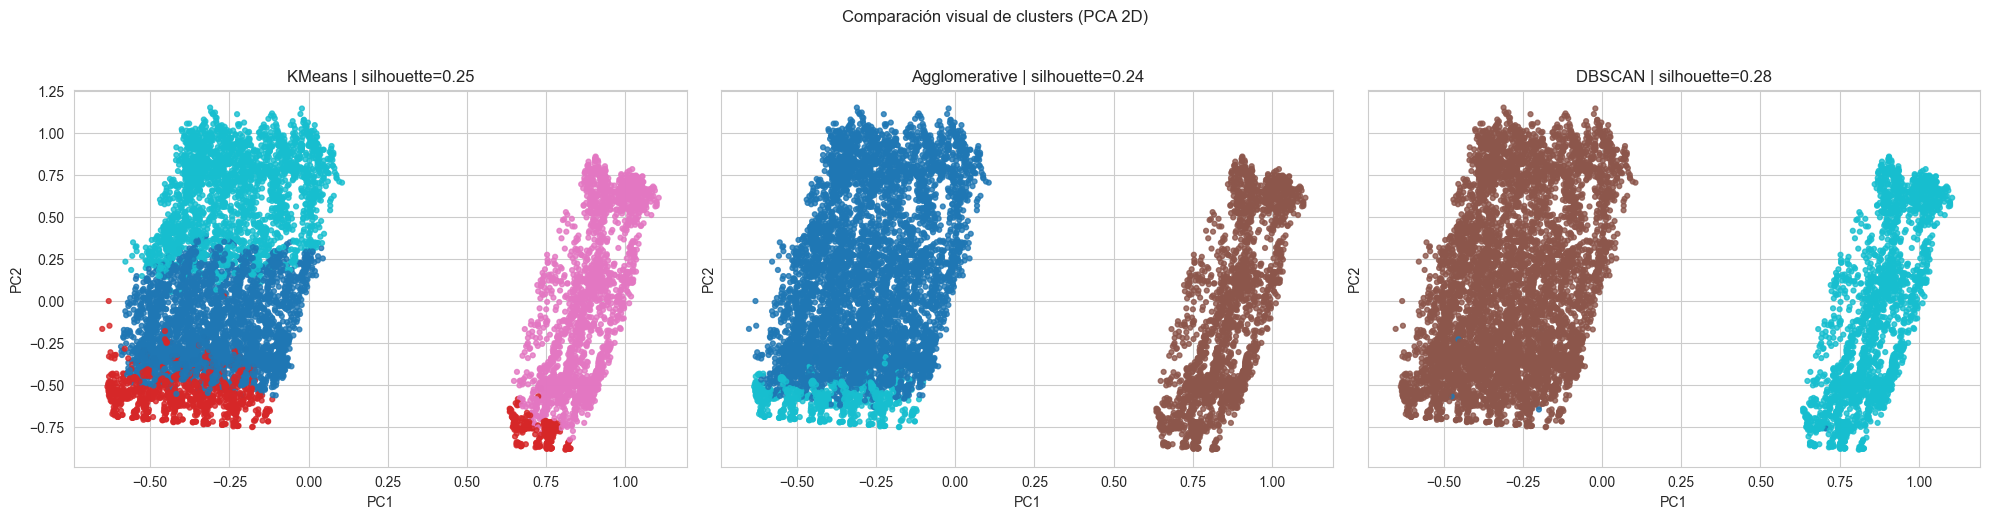

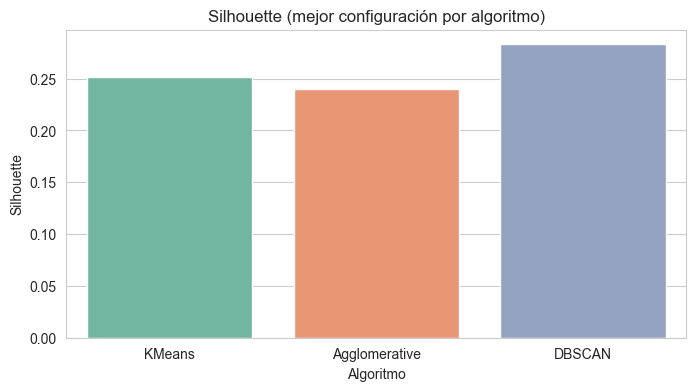

In [ ]:
# Selecciono por algoritmo intentando evitar soluciones casi idénticas.
algo_order = ['KMeans', 'Agglomerative', 'DBSCAN']
selected_rows = []
selected_label_sets = []

for algo in algo_order:
    candidates = rank_df[rank_df['modelo'] == algo].copy()
    if candidates.empty:
        continue

    chosen = None
    for _, row in candidates.iterrows():
        labels_row = np.array(row['labels'])
        if not selected_label_sets:
            chosen = row
            break

        max_ari = max(adjusted_rand_score(labels_row, prev_labels) for prev_labels in selected_label_sets)
        if max_ari < 0.999:
            chosen = row
            break

    if chosen is None:
        # Si no hay alternativa diferente, me quedo con la mejor por silhouette.
        chosen = candidates.iloc[0]

    selected_rows.append(chosen)
    selected_label_sets.append(np.array(chosen['labels']))

best_by_algo = pd.DataFrame(selected_rows).reset_index(drop=True)
display(best_by_algo[['modelo', 'params', 'silhouette', 'noise_ratio', 'min_cluster_size']])

# PCA para visualizar mejor
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X)

fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)
for ax, algo in zip(axes, algo_order):
    subset = best_by_algo[best_by_algo['modelo'] == algo]

    if subset.empty:
        ax.set_title(f"{algo} | sin configuración válida")
        ax.text(0.5, 0.5, 'No disponible en ranking', ha='center', va='center', transform=ax.transAxes)
        ax.set_xlabel('PC1')
        ax.set_ylabel('PC2')
        continue

    row = subset.iloc[0]
    params = row['params']

    if algo == 'KMeans':
        model = KMeans(n_clusters=params['n_clusters'], random_state=SEED, n_init=20)
    elif algo == 'Agglomerative':
        model = AgglomerativeClustering(n_clusters=params['n_clusters'], linkage=params['linkage'])
    else:
        model = DBSCAN(eps=params['eps'], min_samples=params['min_samples'])

    labels = model.fit_predict(X)
    ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10', s=12, alpha=0.8)
    ax.set_title(f"{algo} | silhouette={row['silhouette']:.2f}")
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

plt.suptitle('Comparación visual de clusters (PCA 2D)', y=1.03)
plt.tight_layout()
plt.show()

# Ranking de silhouette por modelo (mejor configuración)
plt.figure(figsize=(8, 4))
sns.barplot(data=best_by_algo, x='modelo', y='silhouette', palette='Set2')
plt.title('Silhouette (mejor configuración por algoritmo)')
plt.ylabel('Silhouette')
plt.xlabel('Algoritmo')
plt.show()

## 11) Selección del modelo final y exportación de resultados

Aunque DBSCAN saca la mejor `silhouette` global, en la decisión final elijo **KMeans** porque para este trabajo me interesa priorizar interpretabilidad y uso práctico.

In [26]:
best_global = rank_df.iloc[0]
best_kmeans_df = rank_df[rank_df['modelo'] == 'KMeans'].sort_values('silhouette', ascending=False).reset_index(drop=True)

# Decisión final para la defensa: priorizo interpretabilidad y estabilidad de uso.
if not best_kmeans_df.empty:
    best = best_kmeans_df.iloc[0]
    criterio_final = 'KMeans seleccionado para el modelo final (interpretabilidad y uso operativo).'
else:
    best = best_global
    criterio_final = 'No había configuración válida de KMeans; se usa el mejor global por silhouette.'

best_modelo = best.get('modelo')
best_params = best.get('params', {})

sil_global = float(best_global['silhouette'])
sil_final = float(best['silhouette'])
delta_sil = sil_global - sil_final

print('Comparación rápida de decisión final:')
display(
    pd.DataFrame([
        {'tipo': 'Mejor global', 'modelo': best_global['modelo'], 'silhouette': sil_global, 'noise_ratio': best_global['noise_ratio']},
        {'tipo': 'Modelo final elegido', 'modelo': best['modelo'], 'silhouette': sil_final, 'noise_ratio': best['noise_ratio']}
    ])
)

print('\nConfiguración final aplicada:')
display(best[['modelo', 'params', 'n_clusters', 'min_cluster_size', 'noise_ratio', 'silhouette']])

if best_modelo == 'KMeans':
    final_model = KMeans(n_clusters=best_params['n_clusters'], random_state=SEED, n_init=20)
elif best_modelo == 'Agglomerative':
    final_model = AgglomerativeClustering(
        n_clusters=best_params['n_clusters'],
        linkage=best_params['linkage']
    )
else:
    final_model = DBSCAN(
        eps=best_params['eps'],
        min_samples=best_params['min_samples']
    )

final_labels = final_model.fit_predict(X)

resultados = df_model.copy()
resultados['cluster'] = final_labels
resultados['modelo_ganador'] = best_modelo

cols_irrelevantes = [
    'pct_pesados', 'intensidad_media_carril', 'speed_bins_total',
    'pct_v_0_50', 'pct_v_50_80', 'pct_v_80_120', 'pct_v_120_255', 'pct_dist_0_6',
    'dia_semana', 'es_fin_de_semana', 'cluster', 'modelo_ganador'
]
resultados_export = resultados.drop(columns=cols_irrelevantes, errors='ignore')

metricas_export = rank_df.drop(columns=['labels']).copy()

out_resultados = BASE_DIR / 'resultados_clustering_trafico.csv'
out_metricas = BASE_DIR / 'metricas_clustering_trafico.csv'

resultados_export.to_csv(out_resultados, index=False, encoding='utf-8-sig')
metricas_export.to_csv(out_metricas, index=False, encoding='utf-8-sig')

print('\nArchivos exportados:')
print(out_resultados.resolve())
print(out_metricas.resolve())

print('\nResumen por cluster (media de variables clave):')
summary_cols = ['vol_total', 'pct_pesados', 'vel_media_pond', 'pct_v_0_50', 'pct_v_80_120', 'hora']
display(resultados.groupby('cluster')[summary_cols].mean().round(2).sort_index())

Comparación rápida de decisión final:


,tipo,modelo,silhouette,noise_ratio
0,Mejor global,DBSCAN,0.282997,0.000529
1,Modelo final elegido,KMeans,0.251422,0.000000



Configuración final aplicada:


modelo                         KMeans
params              {'n_clusters': 4}
n_clusters                          4
min_cluster_size                 1365
noise_ratio                       0.0
silhouette                   0.251422
Name: 0, dtype: object


Archivos exportados:
C:\Users\Asus\Documents\github\ml-dtg\p2\resultados_clustering_trafico.csv
C:\Users\Asus\Documents\github\ml-dtg\p2\metricas_clustering_trafico.csv

Resumen por cluster (media de variables clave):


,vol_total,pct_pesados,vel_media_pond,pct_v_0_50,pct_v_80_120,hora
cluster,,,,,,
0,457.66,10.81,65.13,13.06,14.95,11.83
1,571.68,7.99,32.71,80.94,0.22,13.11
2,675.75,9.66,76.74,9.10,37.75,11.94
3,1684.72,20.61,92.33,1.45,68.86,12.18
